In [1]:
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
from matplotlib import gridspec

import scipy.io
import os

from format_MA_data import save_ma_data

In [2]:
''' set paths '''
save_figs = f"../figures/targeting/"
save_data = f"../data/marissa_data/"
data_folder = 'Z:/Marissa/alignedAnatomy/subcortical/'

In [3]:
''' save data '''
# save_ma_data(data_folder, save_data)

' save data '

In [4]:
''' load numpy arrays '''
data = {}
birds = []

files = os.listdir(data_folder)
for file in files:
    if 'MC' in file: # this is an anatomy file
        file_info = file.split('_')
        if len(file_info) > 2: # has hemisphere label
            bird_id = f'{file_info[0]}_{file_info[1]}'
        else:
            bird_id = file_info[0]
            
        # load numpy array and store in dict
        birds.append(bird_id)
        data[bird_id] = np.load(f'{save_data}{bird_id}.npy')

In [9]:
files = os.listdir(save_data)
files[0].split()

['MC010.npy']

In [4]:
n_birds = len(birds)
print(f'{n_birds} total birds\n')

n_cells = np.zeros(n_birds)
birds_new = []
for i, b in enumerate(birds):
    d = data[b]
    lhy_idx = (d[:, 3] == 3) & (d[:, 0] > 0)
    n_cells[i] = np.sum(lhy_idx)
    
    if n_cells[i]:
        birds_new.append(b)
    
    print(f'{b}: {n_cells[i]} LHY cells')
    
birds = birds_new
n_cells = n_cells[n_cells > 0]
n_birds = len(birds)
print(f'\n{n_birds} birds have LHY labeling')

16 total birds

MC010: 876.0 LHY cells
MC011: 33.0 LHY cells
MC017: 1235.0 LHY cells
MC022: 823.0 LHY cells
MC024: 19.0 LHY cells
MC025: 157.0 LHY cells
MC033_LH: 829.0 LHY cells
MC033_RH: 13.0 LHY cells
MC040: 0.0 LHY cells
MC041_LH: 79.0 LHY cells
MC041_RH: 576.0 LHY cells
MC044: 1324.0 LHY cells
MC045: 735.0 LHY cells
MC046_LH: 0.0 LHY cells
MC046_RH: 0.0 LHY cells
MC047: 13.0 LHY cells

13 birds have LHY labeling


In [10]:
# from https://personal.sron.nl/~pault/#fig:scheme_rainbow_discrete
bird_colors = np.asarray([[209, 187, 215, 255],
                          [174, 118, 163, 255], 
                          [136, 46, 114, 255],
                          [25, 101, 176, 255],
                          [82, 137, 199, 255], 
                          [123, 175, 222, 255],
                          [78, 178, 101, 255],
                          [144, 201, 135, 255],
                          [202, 224, 171, 255],
                          [247, 240, 86, 255],
                          [244, 167, 54, 255],
                          [232, 96, 28, 255],
                          [220, 5, 12, 255]
                         ])/255
bird_colors = list(bird_colors)
for i, c in enumerate(bird_colors):
    bird_colors[i] = tuple(c)

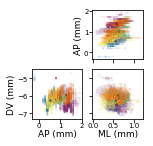

In [162]:
''' plot DV vs. AP coords by bird '''
# font sizes
title_size = 10
axis_label = 9
tick_label = 7

# fig params
gs = gridspec.GridSpec(2, 2, hspace=0.2, wspace=0.2)
f = plt.figure(figsize=(2, 2))
DOT_SIZE = 2
SCALE_DOT = 3*(n_cells / np.max(n_cells))
ALPHA_CELLS = 0.6
ALPHA_AVG = 1

# set plot locations
ax0 = plt.subplot(gs[1, 1])
ax1 = plt.subplot(gs[1, 0])
ax2 = plt.subplot(gs[0, 1])

# plot all cells for each bird
means = np.zeros((n_birds, 3))
for i, b in enumerate(birds):
    d = data[b]
    lhy_idx = (d[:, 3] == 3) & (d[:, 0] > 0)
    if n_cells[i]:
        # get coordinates
        ml = d[lhy_idx, 0]
        dv = d[lhy_idx, 1]
        ap = d[lhy_idx, 2]
        
        # save means (ipsilateral only)
        means[i, :] = np.asarray([np.mean(ml[ml>0]),
                                 np.mean(dv[ml>0]),
                                 np.mean(ap[ml>0])])
        
        ax0.scatter(ml, dv,
                    s=DOT_SIZE, lw=0.1,
                    facecolors='none',
                    edgecolors=bird_colors[i],
                    alpha=ALPHA_CELLS)
        ax1.scatter(ap, dv,
                      s=DOT_SIZE, lw=0.1,
                    facecolors='none',
                    edgecolors=bird_colors[i],
                      alpha=ALPHA_CELLS)
        ax2.scatter(ml, ap,
                      s=DOT_SIZE, lw=0.1,
                    facecolors='none',
                    edgecolors=bird_colors[i],
                      alpha=ALPHA_CELLS) 
        
# plot mean for all birds
SCALE_DOT = SCALE_DOT[means[:, 1] < -1]
means = means[means[:, 1] < -1]
ax0.scatter(means[:, 0], means[:, 1],
              s=DOT_SIZE*SCALE_DOT, lw=0.2,
              facecolors=bird_colors,
            edgecolors='k',
              alpha=ALPHA_AVG)
ax1.scatter(means[:, 2], means[:, 1],
              s=DOT_SIZE*SCALE_DOT, lw=0.2,
              facecolors=bird_colors,
            edgecolors='k',
              alpha=ALPHA_AVG)
ax2.scatter(means[:, 0], means[:, 2],
              s=DOT_SIZE*SCALE_DOT, lw=0.2,
              facecolors=bird_colors,
            edgecolors='k',
              alpha=ALPHA_AVG)

# axes and labels
ax0.set_xlabel('ML (mm)', fontsize=axis_label, labelpad=1)
ax0.tick_params(labelleft=False, which='major', 
                labelsize=tick_label, pad=0.5)
ax0.set_xticks(np.arange(0, 1.2, 0.5))
ax0.set_yticks(np.arange(-7, -4, 1))

ax1.set_xlabel('AP (mm)', fontsize=axis_label, labelpad=1)
ax1.set_ylabel('DV (mm)', fontsize=axis_label, labelpad=1)
ax1.tick_params(which='major', 
                labelsize=tick_label, pad=0.5)
ax1.set_xticks(np.arange(0, 2.2, 1))
ax1.set_yticks(np.arange(-7, -4, 1))

ax2.set_ylabel('AP (mm)', fontsize=axis_label, labelpad=1)
ax2.tick_params(labelbottom=False, which='major', 
                labelsize=tick_label, pad=0.5)
ax2.set_xticks(np.arange(0, 1.2, 0.5))
ax2.set_yticks(np.arange(0, 2.2, 1))

plt.show()
f.savefig(f'{save_figs}lhy_cell_coords.png', dpi=600, bbox_inches='tight')

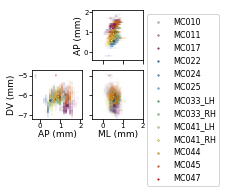

In [14]:
''' plot DV vs. AP coords by bird '''
# font sizes
title_size = 10
axis_label = 9
tick_label = 7

# fig params
gs = gridspec.GridSpec(2, 2, hspace=0.2, wspace=0.2)
f = plt.figure(figsize=(2, 2))
DOT_SIZE = 2
SCALE_DOT = 3*(n_cells / np.max(n_cells))
ALPHA_CELLS = 0.2
ALPHA_AVG = 1

# set plot locations
ax0 = plt.subplot(gs[1, 1])
ax1 = plt.subplot(gs[1, 0])
ax2 = plt.subplot(gs[0, 1])

# plot all cells for each bird
means = np.zeros((n_birds, 3))
for i, b in enumerate(birds):
    d = data[b]
    lhy_idx = (d[:, 3] == 3) & (d[:, 0] > 0)
    if n_cells[i]:
        # get coordinates
        ml = d[lhy_idx, 0]
        dv = d[lhy_idx, 1]
        ap = d[lhy_idx, 2]
        
        # save means (ipsilateral only)
        means[i, :] = np.asarray([np.mean(ml[ml>0]),
                                 np.mean(dv[ml>0]),
                                 np.mean(ap[ml>0])])
        
        ax0.scatter(ml, dv,
                    s=DOT_SIZE, lw=0.1,
                    facecolors='none',
                    edgecolors=bird_colors[i],
                    alpha=ALPHA_CELLS)
        ax1.scatter(ap, dv,
                      s=DOT_SIZE, lw=0.1,
                    facecolors='none',
                    edgecolors=bird_colors[i],
                      alpha=ALPHA_CELLS)
        ax2.scatter(ml, ap,
                    s=DOT_SIZE, lw=0.1,
                    facecolors='none',
                    edgecolors=bird_colors[i],
                    alpha=ALPHA_CELLS) 
        
# plot mean for all birds
SCALE_DOT = SCALE_DOT[means[:, 1] < -1]
means = means[means[:, 1] < -1]
ax0.scatter(means[:, 0], means[:, 1],
              s=DOT_SIZE*SCALE_DOT, lw=0.2,
              facecolors=bird_colors,
            edgecolors='k',
              alpha=ALPHA_AVG)
ax1.scatter(means[:, 2], means[:, 1],
              s=DOT_SIZE*SCALE_DOT, lw=0.2,
              facecolors=bird_colors,
            edgecolors='k',
              alpha=ALPHA_AVG)
ax2.scatter(means[:, 0], means[:, 2],
              s=DOT_SIZE*SCALE_DOT, lw=0.2,
              facecolors=bird_colors,
            edgecolors='k',
              alpha=ALPHA_AVG)

# for legend
for i, b in enumerate(birds):
    ax2.scatter(means[i, 0]+10, means[i, 1]+10,
                s=DOT_SIZE*SCALE_DOT, lw=0.2,
                facecolors=bird_colors[i],
                edgecolors='k',
                label=b,
                alpha=ALPHA_AVG)

# axes and labels
ax0.set_xlabel('ML (mm)', fontsize=axis_label, labelpad=1)
ax0.tick_params(labelleft=False, which='major', 
                labelsize=tick_label, pad=0.5)
ax0.set_xticks(np.arange(0, 3))
ax0.set_yticks(np.arange(-7, -4, 1))
ax0.set_xlim(-0.5, 2)
ax0.set_ylim(-7.2, -4.7)

ax1.set_xlabel('AP (mm)', fontsize=axis_label, labelpad=1)
ax1.set_ylabel('DV (mm)', fontsize=axis_label, labelpad=1)
ax1.tick_params(which='major', 
                labelsize=tick_label, pad=0.5)
ax1.set_xticks(np.arange(0, 2.2, 1))
ax1.set_yticks(np.arange(-7, -4, 1))
ax1.set_xlim(-0.4, 2.1)
ax1.set_ylim(-7.2, -4.7)

ax2.set_ylabel('AP (mm)', fontsize=axis_label, labelpad=1)
ax2.tick_params(labelbottom=False, which='major', 
                labelsize=tick_label, pad=0.5)
ax2.set_xticks(np.arange(0, 3))
ax2.set_yticks(np.arange(0, 2.2, 1))
ax2.set_xlim(-0.5, 2)
ax2.set_ylim(-0.4, 2.1)

plt.legend(bbox_to_anchor=(1,1,0,0), fontsize=8)

plt.show()
f.savefig(f'{save_figs}lhy_coords_scaled.png', dpi=600, bbox_inches='tight')

In [161]:
# center location for each axis
avg_center = np.mean(means, axis=0)

print('target coord for each axis (unweighted):')
print(f'ML = {avg_center[0]:.2} \nDV = {avg_center[1]:.3} \nAP = {avg_center[2]:.3}')

# center location for each axis - weighted avg
weighted_center = np.zeros(3)
for i in range(3):
    axis_mean = means[:, i]
    weighted_center[i] = np.sum(axis_mean*n_cells)/np.sum(n_cells)

print('\ntarget coord for each axis (weighted by n cells):')
print(f'ML = {weighted_center[0]:.2} \nDV = {weighted_center[1]:.3} \nAP = {weighted_center[2]:.3}')

target coord for each axis (unweighted):
ML = 0.52 
DV = -6.03 
AP = 0.826

target coord for each axis (weighted by n cells):
ML = 0.54 
DV = -6.16 
AP = 0.997


In [169]:
# how variable is the centroid across birds for each axis?
range_coords = np.max(means[n_cells > 20], axis=0) - np.min(means[n_cells > 20], axis=0)
print(f'range in center coords (mm):')
print(f'ML = {range_coords[0]:.2} \nDV = {range_coords[1]:.3} \nAP = {range_coords[2]:.3}')

range in center coords (mm):
ML = 0.24 
DV = 0.934 
AP = 0.854


In [27]:
'''
More details:
- What is the correlation between DV and AP? How much rotation are we talking?

'''
b = 'MC017'
d = data[b]
lhy_idx = (d[:, 3] == 3) & (d[:, 0] > 0)

# get coordinates
ml = d[lhy_idx, 0]
dv = d[lhy_idx, 1]
ap = d[lhy_idx, 2]

print(f'{b}')
print(f'ML center = {np.mean(ml[ml>0])}')
print(f'AP center = {np.mean(ap[ml>0])}')
print(f'DV center = {np.mean(dv[ml>0])}')

MC017
ML center = 0.578529773601721
AP center = 1.3694736842105264
DV center = -6.515680884054026


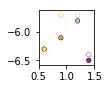

In [34]:
f, ax = plt.subplots(1, 1, figsize=(1, 1))
sub_colors = [bird_colors[0], bird_colors[-3],
              bird_colors[-4], bird_colors[2]]

il_dv = np.asarray([5.7, 5.7, 6.2, 6.4])*-1
ma_dv = np.asarray([5.8, 6.1, 6.3, 6.5])*-1
ap = np.asarray([1.2, 0.9, 0.6, 1.4])

ax.scatter(ap, il_dv, s=20, 
           lw=0.5,
           facecolors='none',
           edgecolors=sub_colors, zorder=0)
ax.scatter(ap, ma_dv, s=20, 
           lw=0.5,
           facecolors=sub_colors,
           edgecolors='k', zorder=1)
ax.set_xticks([0.5, 1, 1.5])

f.savefig(f'{save_figs}center_coords_compare.png', dpi=600, bbox_inches='tight')
plt.show()

In [81]:
# within bird extent of the region along each axis
extent = np.zeros((n_birds, 3))
for i, b in enumerate(birds):
    d = data[b]
    lhy_idx = (d[:, 3] == 3) & (d[:, 0] > 0)
    if n_cells[i]:
        # get coordinates
        coords = d[lhy_idx, :3]
        extent[i] = np.max(coords, axis=0) - np.min(coords, axis=0)
        
print(f'within bird LHY extent (mm) (mean, sem):')
print(f'ML = {np.mean(extent[:, 0]):.2}, {stats.sem(extent[:, 0]):.2}')
print(f'DV = {np.mean(extent[:, 1]):.2}, {stats.sem(extent[:, 1]):.2}')
print(f'AP = {np.mean(extent[:, 2]):.2}, {stats.sem(extent[:, 2]):.2}')

within bird LHY extent (mm) (mean, sem):
ML = 0.6, 0.079
DV = 1.0, 0.16
AP = 0.55, 0.12


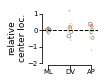

In [173]:
# relative center locations
norm_centers = (means - weighted_center)

# fig params
f, ax = plt.subplots(1, 1, figsize=(1, 1))
SCALE_DOT = n_cells / np.max(n_cells)
DOT_SIZE = 15*SCALE_DOT
MEAN_SIZE = 20
JIT = np.random.randn(n_birds) * 0.03
axes = np.asarray([1, 2, 3])

# for each bird
ax.scatter(np.full(n_birds, axes[0])+JIT, norm_centers[:, 0],
           s=DOT_SIZE, lw=0.5,
           facecolors='none',
           edgecolors=bird_colors, 
           alpha=1) # ML
ax.scatter(np.full(n_birds, axes[1])+JIT, norm_centers[:, 1],
           s=DOT_SIZE, lw=0.5,
           facecolors='none',
           edgecolors=bird_colors,
           alpha=1) # DV
ax.scatter(np.full(n_birds, axes[2])+JIT, norm_centers[:, 2],
           s=DOT_SIZE, lw=0.5,
           facecolors='none',
           edgecolors=bird_colors,
           alpha=1) # AP

# means
ax.hlines(0, 0.7, 3.3, lw=1, linestyles='dashed', colors='k')

# axis params
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_bounds(-2, 1)
ax.spines['bottom'].set_bounds(1, 3)
ax.set_ylim([-2.1, 1.2])
ax.set_xlim([0.7, 3.3])

# ticks and labels
ax.set_yticks(np.arange(-2, 2))
ax.set_xticks(axes)
ax.set_xticklabels(['ML', 'DV', 'AP'])
ax.tick_params(which='major', 
                labelsize=tick_label, pad=0.5)
ax.set_ylabel('relative\ncenter loc.', fontsize=axis_label, labelpad=1)

plt.show()
f.savefig(f'{save_figs}center_locations.png', dpi=600, bbox_inches='tight')

In [113]:
n_cells

13